In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install tensorflow keras opencv-python scikit-image imutils 

Note: you may need to restart the kernel to use updated packages.


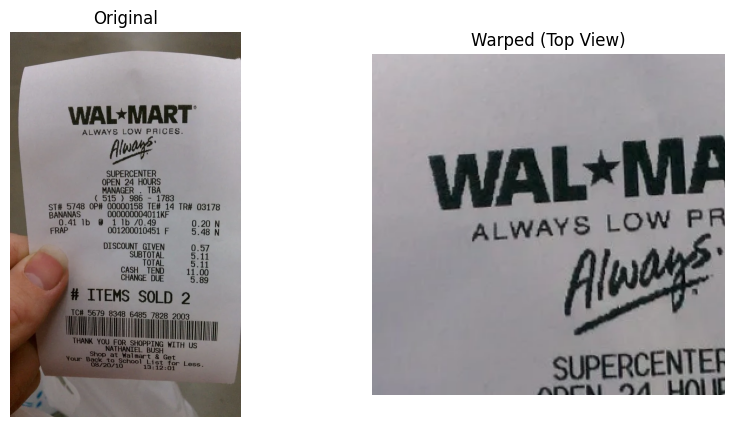

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def order_points(pts):
    """
    Order points as:
    top-left, top-right, bottom-right, bottom-left
    """
    pts = np.array(pts, dtype="float32")

    rect = np.zeros((4, 2), dtype="float32")

    # Sum of points (x + y)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right

    # Difference (x - y)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect


def four_point_transform(image, pts):
    """
    Perform perspective transform
    """
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute width
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = int(max(widthA, widthB))

    # Compute height
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = int(max(heightA, heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # Perspective transform matrix
    M = cv2.getPerspectiveTransform(rect, dst)

    # Apply warp
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped


# ==============================
# 🔹 Example Usage (IMPORTANT)
# ==============================

# Load image (change path)
image = cv2.imread("/kaggle/input/datasets/anderianisar/ai-lab-6/images/0.jpg")

if image is None:
    raise ValueError("Image not found. Check file path.")

# Convert BGR to RGB for matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Example 4 points (YOU MUST CHANGE THESE)
pts = np.array([
    [100, 100],   # top-left
    [400, 120],   # top-right
    [380, 400],   # bottom-right
    [120, 390]    # bottom-left
], dtype="float32")

# Apply transform
warped = four_point_transform(image, pts)

# Show results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Warped (Top View)")
plt.imshow(warped)
plt.axis("off")

plt.show()

Task 1.2: Automatic Deskewing 

In [11]:
import cv2
import numpy as np


def deskew(image):
    """
    Deskew (auto-rotate) an image based on text orientation
    Returns: rotated image, detected angle
    """

    # 🔹 Check if image is valid
    if image is None:
        raise ValueError("Invalid image: None received")

    # 🔹 Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 🔹 Invert colors (text becomes white)
    gray = cv2.bitwise_not(gray)

    # 🔹 Threshold (binarization)
    thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    # 🔹 Get coordinates of non-zero pixels
    coords = np.column_stack(np.where(thresh > 0))

    # ❗ Handle case when no foreground pixels found
    if coords.shape[0] == 0:
        return image, 0.0

    # 🔹 Get angle from minimum area rectangle
    angle = cv2.minAreaRect(coords)[-1]

    # 🔹 Adjust angle
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # 🔹 Rotate image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle

Task 1.3: Morphological Operations

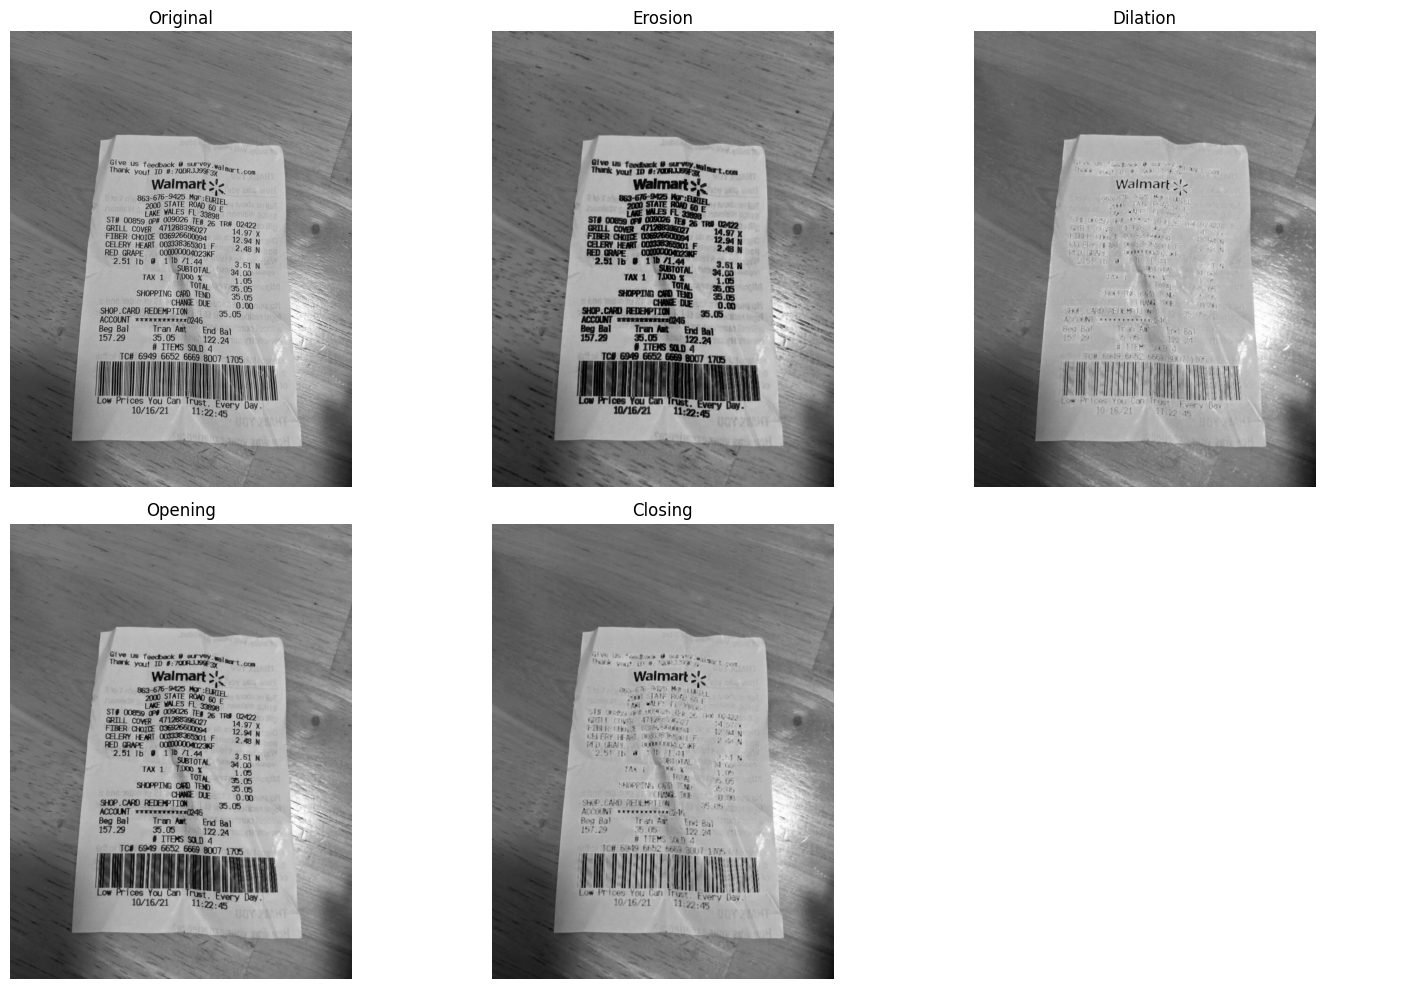

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 🔹 Load Image
# ==============================
img = cv2.imread('/kaggle/input/datasets/anderianisar/ai-lab-6/images/19.jpg')

if img is None:
    raise ValueError("Image not found. Check file path.")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==============================
# 🔹 Define Kernel
# ==============================
kernel = np.ones((3, 3), np.uint8)

# ==============================
# 🔹 Morphological Operations
# ==============================

# Erosion - remove noise
erosion = cv2.erode(gray, kernel, iterations=1)

# Dilation - fill gaps
dilation = cv2.dilate(gray, kernel, iterations=1)

# Opening - erosion followed by dilation
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

# Closing - dilation followed by erosion
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

# ==============================
# 🔹 Display Results
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')
axes[0, 1].axis('off')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')
axes[0, 2].axis('off')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing')
axes[1, 1].axis('off')

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

PART 2: BUILD CNN FROM SCRATCH 

Task 2.1: Load MNIST Dataset 

In [16]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# ==============================
# 🔹 Load MNIST Dataset
# =============================
import numpy as np

data = np.load("/kaggle/input/datasets/anderianisar/mnist-dataset/mnist.npz")

x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

In [17]:
from tensorflow import keras

# ==============================
# 🔹 Reshape (add channel dimension)
# ==============================
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# ==============================
# 🔹 Normalize (0–1 range)
# ==============================
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# ==============================
# 🔹 Convert labels to one-hot encoding
# ==============================
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

# ==============================
# 🔹 Create CNN Model
# ==============================
model = keras.Sequential([
    
    # First convolutional block
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(10, activation='softmax')
])

# ==============================
# 🔹 Model Summary
# ==============================
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 07:48:40.255011: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ==============================
# 🔹 Compile Model
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 🔹 Train Model
# ==============================
history = model.fit(
    x_train, 
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

# ==============================
# 🔹 Evaluate Model
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7924 - loss: 0.6621 - val_accuracy: 0.9802 - val_loss: 0.0682
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9680 - loss: 0.1072 - val_accuracy: 0.9875 - val_loss: 0.0461
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9764 - loss: 0.0788 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9803 - loss: 0.0635 - val_accuracy: 0.9890 - val_loss: 0.0381
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9841 - loss: 0.0531 - val_accuracy: 0.9908 - val_loss: 0.0367
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9871 - loss: 0.0445 - val_accuracy: 0.9905 - val_loss: 0.0368
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9884 - loss: 0.0367 - val_accuracy: 0.9910 - val_loss: 0.0356
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9888 - loss: 0.0340 - 